In [1]:
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.system('cp /teamspace/studios/this_studio/kaggle.json ~/.kaggle/kaggle.json')

cp: cannot stat '/teamspace/studios/this_studio/kaggle.json': No such file or directory


256

In [2]:
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset --path /teamspace/studios/this_studio/for_data
print("Done!")

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
the-fake-or-real-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Done!


In [3]:
import zipfile
print("Unzipping...")
with zipfile.ZipFile('/teamspace/studios/this_studio/for_data/the-fake-or-real-dataset.zip', 'r') as z:
    z.extractall('/teamspace/studios/this_studio/for_data')
print("Done!")

Unzipping...
Done!


In [4]:
!pip install librosa -q

import os, librosa, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score

class AudioDataset(Dataset):
    def __init__(self, root):
        self.samples = []
        for label, cls in enumerate(['real', 'fake']):
            folder = os.path.join(root, cls)
            for f in os.listdir(folder):
                if f.endswith('.wav') or f.endswith('.mp3'):
                    self.samples.append((os.path.join(folder, f), label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            y, sr = librosa.load(path, sr=16000, duration=3.0)
            if len(y) < 48000:
                y = np.pad(y, (0, 48000 - len(y)))
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
            mfcc = (mfcc - mfcc.mean()) / (mfcc.std() + 1e-6)
            mfcc = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0)
        except:
            mfcc = torch.zeros(1, 40, 94)
        return mfcc, label

base = '/teamspace/studios/this_studio/for_data/for-2sec/for-2seconds'
train_ds = AudioDataset(os.path.join(base, 'training'))
val_ds   = AudioDataset(os.path.join(base, 'validation'))
test_ds  = AudioDataset(os.path.join(base, 'testing'))
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 13956 | Val: 2826 | Test: 1088


In [5]:
class AudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.fc(self.cnn(x))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_audio = AudioCNN().to(device)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4)

optimizer = torch.optim.Adam(model_audio.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
best_acc  = 0

train_losses, val_accs = [], []

for epoch in range(10):
    model_audio.train()
    epoch_loss = 0
    for i, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model_audio(x), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        if i % 50 == 0:
            print(f"Epoch {epoch+1} | Step {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    model_audio.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            out = model_audio(x.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())

    acc = accuracy_score(labels, preds) * 100
    val_accs.append(acc)
    print(f"\nEpoch {epoch+1} | Train Loss: {avg_loss:.4f} | Val Acc: {acc:.2f}%\n")

    if acc > best_acc:
        best_acc = acc
        torch.save(model_audio.state_dict(), '/teamspace/studios/this_studio/best_voice_model.pth')
        print(f"Saved! Best Val Acc: {best_acc:.2f}%")

print(f"\nDone! Best Val Acc: {best_acc:.2f}%")

Using device: cuda
Epoch 1 | Step 0/437 | Loss: 0.6949
Epoch 1 | Step 50/437 | Loss: 0.6558
Epoch 1 | Step 100/437 | Loss: 0.4771
Epoch 1 | Step 150/437 | Loss: 0.3856
Epoch 1 | Step 200/437 | Loss: 0.2898
Epoch 1 | Step 250/437 | Loss: 0.3108
Epoch 1 | Step 300/437 | Loss: 0.1252
Epoch 1 | Step 350/437 | Loss: 0.2447
Epoch 1 | Step 400/437 | Loss: 0.3496

Epoch 1 | Train Loss: 0.3838 | Val Acc: 95.51%

Saved! Best Val Acc: 95.51%
Epoch 2 | Step 0/437 | Loss: 0.1804
Epoch 2 | Step 50/437 | Loss: 0.2641
Epoch 2 | Step 100/437 | Loss: 0.1016
Epoch 2 | Step 150/437 | Loss: 0.0862
Epoch 2 | Step 200/437 | Loss: 0.1137
Epoch 2 | Step 250/437 | Loss: 0.0602
Epoch 2 | Step 300/437 | Loss: 0.0993
Epoch 2 | Step 350/437 | Loss: 0.0290
Epoch 2 | Step 400/437 | Loss: 0.1960

Epoch 2 | Train Loss: 0.1368 | Val Acc: 96.96%

Saved! Best Val Acc: 96.96%
Epoch 3 | Step 0/437 | Loss: 0.0329
Epoch 3 | Step 50/437 | Loss: 0.0137
Epoch 3 | Step 100/437 | Loss: 0.1117
Epoch 3 | Step 150/437 | Loss: 0.0293


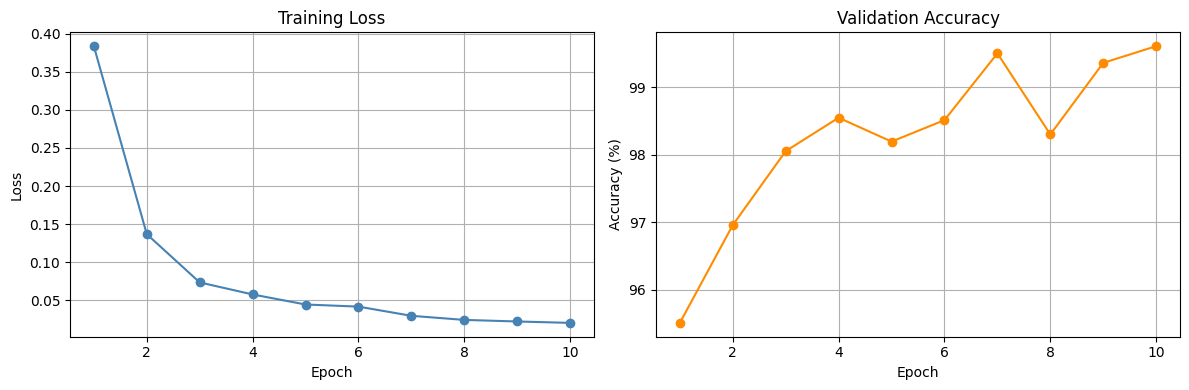

Saved: audio_training_curves.png


In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(train_losses)+1), train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, len(val_accs)+1), val_accs, marker='o', color='darkorange')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)

plt.tight_layout()
plt.savefig('/teamspace/studios/this_studio/audio_training_curves.png', dpi=150)
plt.show()
print("Saved: audio_training_curves.png")

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model
model_audio.load_state_dict(torch.load(
    '/teamspace/studios/this_studio/best_voice_model.pth',
    map_location=device, weights_only=False
))
model_audio.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        out  = model_audio(x.to(device))
        prob = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(prob)

acc  = accuracy_score(all_labels, all_preds)  * 100
prec = precision_score(all_labels, all_preds) * 100
rec  = recall_score(all_labels, all_preds)    * 100
f1   = f1_score(all_labels, all_preds)        * 100
auc  = roc_auc_score(all_labels, all_probs)

print("=== Test Set Results ===")
print(f"Accuracy  : {acc:.2f}%")
print(f"Precision : {prec:.2f}%")
print(f"Recall    : {rec:.2f}%")
print(f"F1-Score  : {f1:.2f}%")
print(f"AUC-ROC   : {auc:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

=== Test Set Results ===
Accuracy  : 86.21%
Precision : 88.93%
Recall    : 82.72%
F1-Score  : 85.71%
AUC-ROC   : 0.9380

              precision    recall  f1-score   support

        Real       0.84      0.90      0.87       544
        Fake       0.89      0.83      0.86       544

    accuracy                           0.86      1088
   macro avg       0.86      0.86      0.86      1088
weighted avg       0.86      0.86      0.86      1088



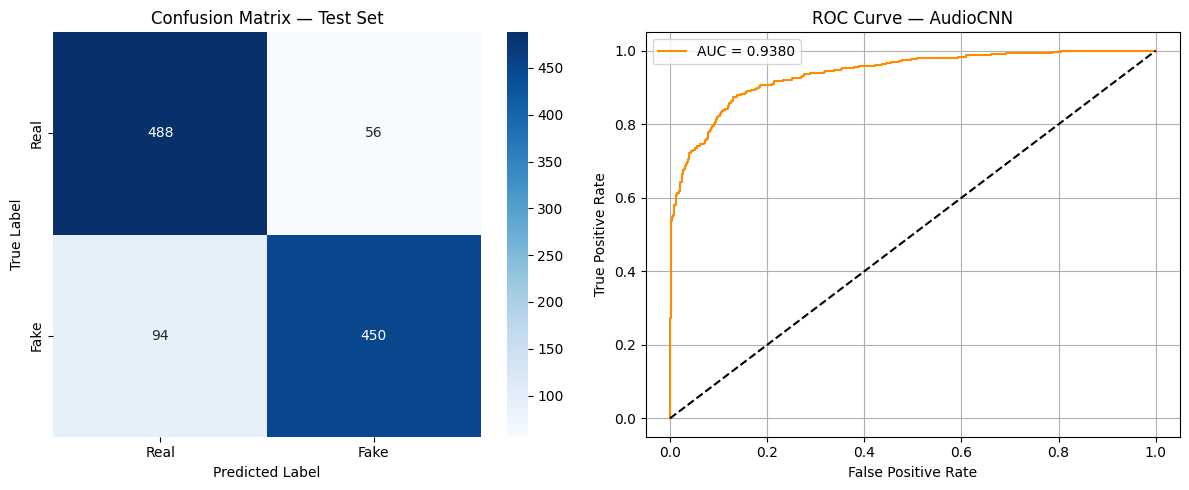

Saved: audio_evaluation.png


In [8]:
from sklearn.metrics import roc_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'], ax=ax1)
ax1.set_title('Confusion Matrix — Test Set')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
ax2.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc:.4f}')
ax2.plot([0,1], [0,1], 'k--')
ax2.set_title('ROC Curve — AudioCNN')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/teamspace/studios/this_studio/audio_evaluation.png', dpi=150)
plt.show()
print("Saved: audio_evaluation.png")